# Simple LightGBM baseline

Цель этого ноутбука — получить первое значение качества модели до сложного feature engineering.
В baseline используются только признаки из:
`application_train.csv`

В этом ноутбуке нет:

- временных окон;
- trend-признаков;
- KMeans-признаков;
- подбора гиперпараметров через Optuna.

Задача baseline — понять, какое качество можно получить только из информации текущей заявки и затем измерять прирост от следующих этапов проекта.

Основная метрика — ROC-AUC.

## Загрузка данных

Для простой модели используются: `application_train.csv`


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve
from lightgbm.callback import early_stopping, log_evaluation

import lightgbm as lgb

In [4]:
path_to_data = "/home/usl/PycharmProjects/home-credit-default-risk/data/raw/home-credit-default-risk/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")

## Train / validation split
Для baseline используется фиксированный stratified holdout:

- 80% данных — train;
- 20% — validation;
- `random_state=42`;
- `stratify=y`.

Stratification используется из-за сильного дисбаланса классов и сохраняет одинаковую долю `TARGET=1` в train и validation.

`SK_ID_CURR` удаляется из модельных признаков, поскольку является техническим идентификатором.

In [5]:
X = application_train_df.drop(columns=["TARGET", "SK_ID_CURR"])
y = application_train_df["TARGET"].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("TARGET full:", y.mean())
print("TARGET train:", y_train.mean())
print("TARGET val:", y_val.mean())

X_train: (246008, 120)
X_val: (61503, 120)
TARGET full: 0.08072881945686496
TARGET train: 0.08072908198107379
TARGET val: 0.08072776937710356


## Категориальные признаки

LightGBM умеет работать с категориальными признаками напрямую, поэтому One-Hot Encoding для baseline не используется.
Категории определяются только по `X_train`.
Validation и test получают тот же набор категорий.

In [6]:
cat_cols = X_train.select_dtypes(include = 'object').columns.tolist()
len(cat_cols)

16

In [7]:
for col in cat_cols:
    categories = (X_train[col].dropna().unique())
    X_train[col] = pd.Categorical(X_train[col], categories=categories)
    X_val[col] = pd.Categorical(X_val[col], categories=categories)

print("Categorical features:", len(cat_cols))

Categorical features: 16


## Baseline LightGBM

В качестве первой модели используется `LGBMClassifier`.
Почему LightGBM подходит для baseline:

- данные табличные;
- одновременно присутствуют числовые и категориальные признаки;
- много пропусков;
- возможны нелинейные зависимости и взаимодействия признаков;
- модель не требует масштабирования числовых признаков.

На этом этапе параметры специально не подбираются через Optuna, так как в этом ноутбуке необходимо получить стартовую оценку качества модели.

In [9]:
lgb_clf = lgb.LGBMClassifier(n_estimators=1000, max_depth=4, learning_rate=0.1, random_state = 42, n_jobs=-1, verbosity=-1)
lgb_clf.fit(X_train, y_train, eval_set = [(X_val, y_val)], eval_metric='auc', categorical_feature=cat_cols, callbacks = [early_stopping(stopping_rounds=100), log_evaluation(period = 100)])

threshold = 0.5
val_pred_proba = lgb_clf.predict_proba(X_val)[:, 1]
val_pred = (val_pred_proba >= threshold).astype(int)


roc_auc_lgb = roc_auc_score(y_val, val_pred_proba)
prec_lgb = precision_score(y_val, val_pred, zero_division=0)
rec_lgb = recall_score(y_val, val_pred, zero_division=0)

print("Best_iteration:", lgb_clf.best_iteration_)
print("ROC-AUC_lgb:", roc_auc_lgb)
print("Precision_lgb:", prec_lgb)
print("Recall_lgb:", rec_lgb)

/home/usl/PycharmProjects/home-credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.75828	valid_0's binary_logloss: 0.245984
[200]	valid_0's auc: 0.760298	valid_0's binary_logloss: 0.245173
[300]	valid_0's auc: 0.760767	valid_0's binary_logloss: 0.245061
Early stopping, best iteration is:
[277]	valid_0's auc: 0.760964	valid_0's binary_logloss: 0.244994
Best_iteration: 277
ROC-AUC_lgb: 0.7609642466311548
Precision_lgb: 0.5670103092783505
Recall_lgb: 0.022155085599194362


## Оценка baseline

Получены:

- ROC-AUC: `0.760964`;
- Precision при пороге 0.5: `0.5670`;
- Recall при пороге 0.5: `0.0222`;
- Best iteration: `277`.

Основной результат этого эксперимента — ROC-AUC.

ROC-AUC показывает способность модели ранжировать клиентов по риску независимо от конкретного порога классификации.

Низкий Recall при `threshold = 0.5` не означает, что модель не умеет находить рискованных клиентов. Причина в сильном дисбалансе классов и в том, что порог `0.5` здесь выбран только для иллюстрации.

Порог отдельно не оптимизируется, поскольку основной метрикой соревнования и проекта является ROC-AUC.

### Confusion matrix при threshold = 0.5

Confusion matrix добавлена для иллюстрации поведения модели при фиксированном пороге:

Text(0.5, 1.0, 'Confusion Matrix LightGBM')

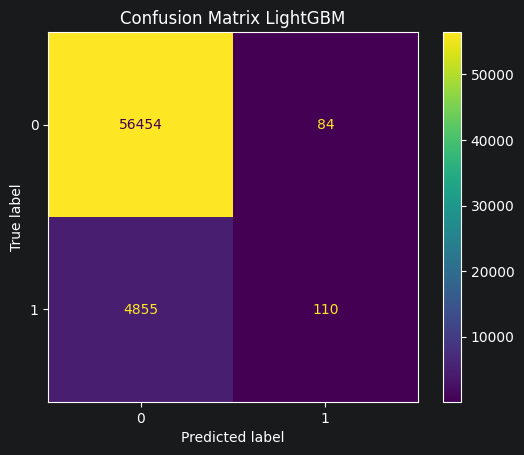

In [10]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Confusion Matrix LightGBM")

### ROC curve

ROC-кривая показывает trade-off между True Positive Rate и False Positive Rate для всех возможных порогов.
Диагональ соответствует случайному классификатору с ROC-AUC = 0.5.

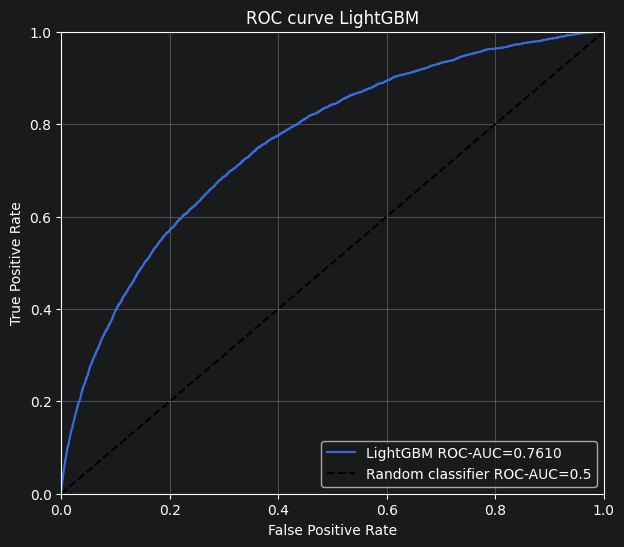

In [11]:
fpr, tpr, thresholds = roc_curve(y_val, val_pred_proba)
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, label = f"LightGBM ROC-AUC={roc_auc_lgb:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label = "Random classifier ROC-AUC=0.5")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve LightGBM")
plt.legend(loc="lower right")
plt.grid()

## Результат baseline

Простая модель, использующая только признаки текущей заявки, получила:

**ROC-AUC = 0.76096**

при:

**best iteration = 277**


# Итоги baseline

В этом ноутбуке построена первая версия модели только на данных текущей заявки.
Получен локальный ROC-AUC: **0.76096**

Baseline подтвердил, что LightGBM подходит для дальнейших экспериментов и позволяет напрямую работать с категориальными признаками и пропусками.
Главное ограничение текущей версии — отсутствие кредитной истории клиента.
Следующий этап — `03_feature_engineering.ipynb`, где исторические таблицы агрегируются до уровня `SK_ID_CURR` и создаются признаки кредитной нагрузки, просрочек, платежной дисциплины, временных окон и trends.